<a href="https://colab.research.google.com/github/rendyamril/data-science-2026/blob/main/Pertemuan11_MohammadRendyAmril_24040101028.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Nama : Mohammad Rendy Amril
* NIM : 240401010288
* Prodi : S1 PJJ Informatika
* Kelas : IF 403

Ukuran Data: (300, 4)

Statistik Deskriptif:
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.80         53.23   42.07
std                 33.86         27.41   13.59
min                  9.04          0.12   18.00
25%                 32.86         27.00   30.00
50%                 70.63         55.09   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


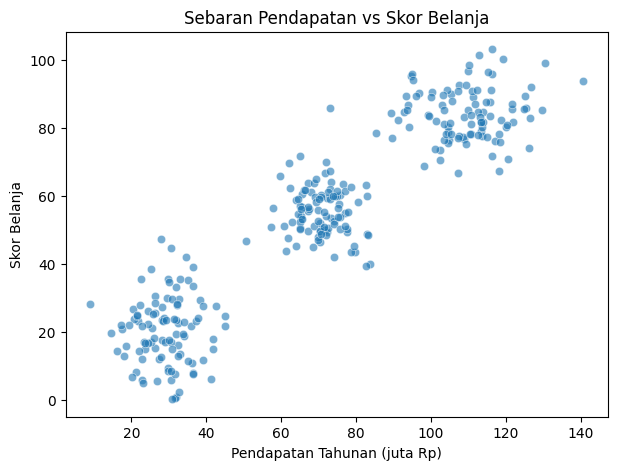

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate dataset sintetis (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [8, 10], (100, 2))   # Kelompok Hemat
grp2 = np.random.normal([70, 55], [6, 8], (100, 2))    # Kelompok Menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # Kelompok Boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

# 2. Ringkasan Data
print("Ukuran Data:", df.shape)
print("\nStatistik Deskriptif:")
print(df.describe().round(2))

# 3. Visualisasi Awal
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.show()

In [2]:
from sklearn.preprocessing import StandardScaler

# Ambil fitur numerik
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling:', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling: [1. 1.]


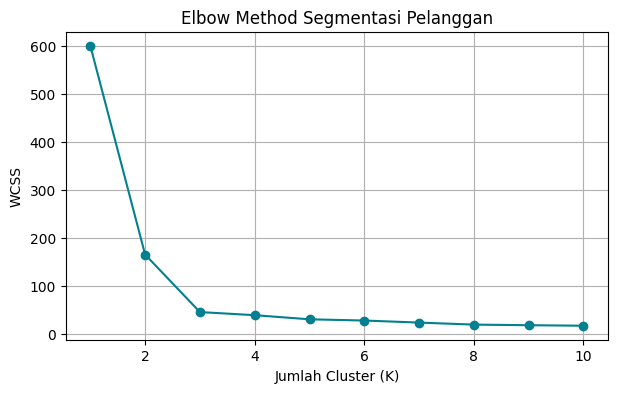

In [3]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method Segmentasi Pelanggan')
plt.grid(True)
plt.show()

In [4]:
from sklearn.metrics import silhouette_score

# Fit K-Means dengan K=3
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)

df['cluster'] = model.labels_

print(f'WCSS Akhir        : {model.inertia_:.3f}')
print(f'Silhouette Score  : {silhouette_score(X_scaled, model.labels_):.3f}')
print("\nRata-Rata Karakteristik Tiap Cluster:")
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS Akhir        : 44.919
Silhouette Score  : 0.699

Rata-Rata Karakteristik Tiap Cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.75         55.04
1                     29.08         20.34
2                    109.19         84.01


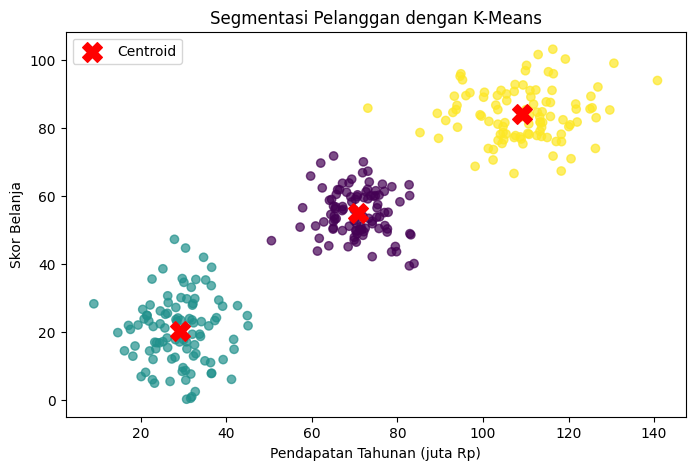

In [5]:
# Kembalikan koordinat centroid ke skala asli
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
            c=df['cluster'], cmap='viridis', alpha=0.7)

plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroid')

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

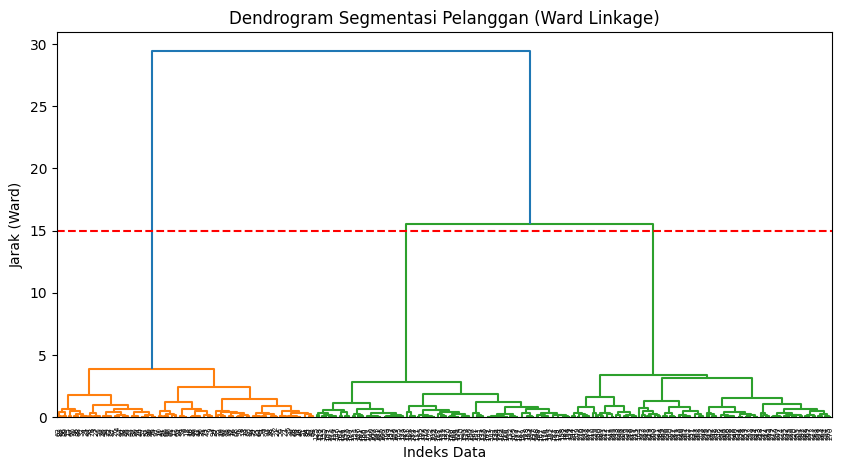

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # Garis pemotong
plt.show()

**Kesimpulan** <br>
Modul ini membahas teknik *Unsupervised Learning* untuk mengelompokkan data tanpa label menggunakan *K-Means* dan *Hierarchical Clustering*. Pembahasan mencakup optimasi *WCSS*, penentuan jumlah cluster ($K$) optimal lewat Metode *Elbow* dan *Silhouette Score*, serta pemetaan struktur data bertingkat menggunakan visualisasi *dendrogram*.

**Temuan Utama** <br>
* *K-Means* mengelompokkan data berdasarkan jarak ke *centroid*, sedangkan *Hierarchical Clustering* membentuk pohon hierarki (*dendrogram*).
* Metode *Elbow* dan *Silhouette Score* membantu menentukan jumlah cluster ideal.

**Pertanyaan yang Muncul** <br>
Bagaimana menangani data dengan skala berbeda dan bentuk cluster tak beraturan agar hasil *K-Means* tetap optimal tanpa terdistorsi oleh *outlier*?